# Morphology in Binary Images

## Erosion, Dilation, Opening, and Closing

This notebook introduces the main morphological operations used in **binary image processing**:

- **Erosion**
- **Dilation**
- **Opening**
- **Closing**

It includes:
- concise theory
- equations for each operation
- simple Python examples
- visual demonstrations
- student tasks
- challenge exercises

---
## Learning objectives

By the end of this notebook, students should be able to:

1. explain the role of a **structuring element**
2. apply erosion and dilation to binary images
3. distinguish between opening and closing
4. interpret how morphology changes object boundaries and noise
5. implement these operations in Python


## 1. Binary Images

A **binary image** contains only two possible pixel values, usually:

- **1** for foreground (object)
- **0** for background

Morphological operations process the shape of foreground objects using a small mask called a **structuring element**.

---
## 2. Structuring Element

A structuring element is a small binary pattern, for example:

$$
B =
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

This kernel slides over the image and determines how the foreground is modified.


## 3. Erosion

Erosion **shrinks** foreground objects.

### Set-theoretic equation

$$
A \ominus B = \{ z \mid B_z \subseteq A \}
$$

Where:
- \(A\) is the binary image (foreground set)
- \(B\) is the structuring element
- \(B_z\) is the translation of \(B\) by \(z\)

### Intuition

A foreground pixel remains 1 **only if** the structuring element fits completely inside the object at that location.

### Effect of erosion

- removes small white noise
- thins objects
- breaks narrow connections
- shrinks boundaries


## 4. Dilation

Dilation **expands** foreground objects.

### Set-theoretic equation

$$
A \oplus B = \{ z \mid (\hat{B})_z \cap A \neq \emptyset \}
$$

A common intuitive interpretation is:
- a pixel becomes foreground if **any** relevant part of the structuring element overlaps the object

### Effect of dilation

- enlarges objects
- fills tiny holes
- connects nearby components
- thickens boundaries


## 5. Opening

Opening is erosion followed by dilation.

### Equation

$$
A \circ B = (A \ominus B) \oplus B
$$

### Effect of opening

- removes small bright objects
- smooths boundaries
- preserves larger object shape better than erosion alone

Opening is useful when the image contains **small foreground noise**.


## 6. Closing

Closing is dilation followed by erosion.

### Equation

$$
A \bullet B = (A \oplus B) \ominus B
$$

### Effect of closing

- fills small holes in objects
- closes small gaps
- connects nearby foreground regions
- smooths boundaries

Closing is useful when objects contain **small black holes or gaps**.


## 7. Import libraries

The examples below use:
- **NumPy** for array creation
- **Matplotlib** for display
- **OpenCV** for morphology

Run the next cell first.


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 8. Create a simple binary image

We will generate a synthetic binary image with:
- one main square object
- a small noise dot
- a small hole inside the object


In [4]:
img = np.zeros((12, 12), dtype=np.uint8)

# Main object
img[3:9, 3:9] = 1

# Small hole inside the object
img[5, 5] = 0

# Small foreground noise
img[1, 10] = 1

print(img)

[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 1 1 0 1 1 1 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


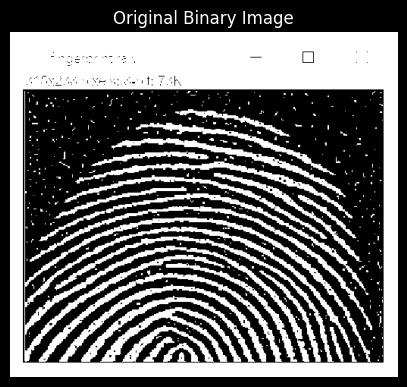

In [3]:
img = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week11/finger.png", cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.title("Original Binary Image")
plt.axis("off")
plt.show()

## 9. Define the structuring element

Here we use a 3×3 square kernel.


In [5]:
kernel = np.ones((3, 3), dtype=np.uint8)
print(kernel)

[[1 1 1]
 [1 1 1]
 [1 1 1]]


## 10. Apply erosion

Observe how:
- the object becomes smaller
- the tiny noise dot disappears
- narrow details can be lost


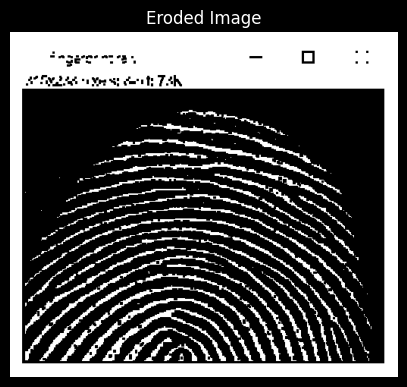

[[254 254 254 ... 253 254 254]
 [254 254 254 ... 253 253 254]
 [254 254 254 ... 253 253 253]
 ...
 [253 252 252 ... 248 249 250]
 [253 253 252 ... 249 250 251]
 [253 253 252 ... 250 251 251]]


In [8]:
eroded = cv2.erode(img, kernel, iterations=1)
img = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week11/finger.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5, 5))
plt.imshow(eroded, cmap='gray', vmin=0, vmax=1)
plt.title("Eroded Image")
plt.axis("off")
plt.show()

print(eroded)

## 11. Apply dilation

Observe how:
- the object grows
- the small hole may reduce or disappear
- small components can become larger


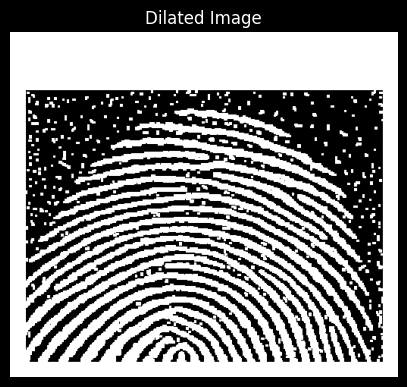

[[255 255 255 ... 254 254 254]
 [255 255 255 ... 254 254 254]
 [255 255 254 ... 254 254 254]
 ...
 [254 254 253 ... 251 252 252]
 [254 254 254 ... 252 252 252]
 [254 254 254 ... 252 252 252]]


In [9]:
dilated = cv2.dilate(img, kernel, iterations=1)

plt.figure(figsize=(5, 5))
plt.imshow(dilated, cmap='gray', vmin=0, vmax=1)
plt.title("Dilated Image")
plt.axis("off")
plt.show()

print(dilated)

## 12. Apply opening

Opening = erosion + dilation

It is often used to remove small foreground noise while keeping the main object.


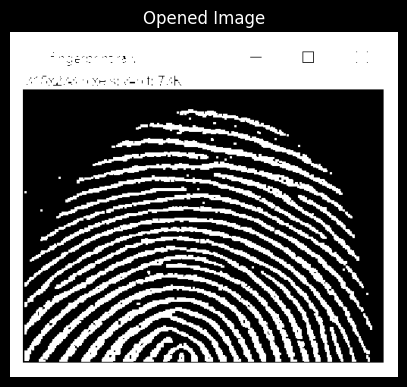

[[254 254 254 ... 254 254 254]
 [254 254 254 ... 254 254 254]
 [254 254 254 ... 253 254 254]
 ...
 [253 253 253 ... 250 251 251]
 [253 253 253 ... 251 251 251]
 [253 253 253 ... 251 251 251]]


In [10]:
opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(5, 5))
plt.imshow(opened, cmap='gray', vmin=0, vmax=1)
plt.title("Opened Image")
plt.axis("off")
plt.show()

print(opened)

## 13. Apply closing

Closing = dilation + erosion

It is often used to fill small holes and close small breaks.


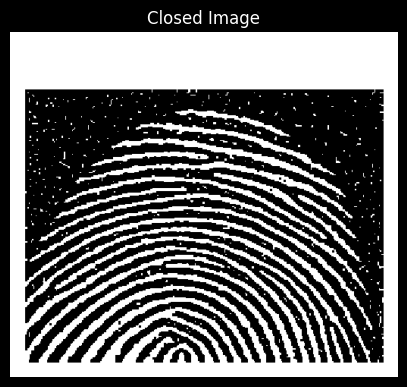

[[255 255 255 ... 254 254 254]
 [255 254 254 ... 254 254 254]
 [254 254 254 ... 253 254 254]
 ...
 [253 253 253 ... 250 251 251]
 [254 253 253 ... 251 251 252]
 [254 254 253 ... 251 252 252]]


In [11]:
closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(5, 5))
plt.imshow(closed, cmap='gray', vmin=0, vmax=1)
plt.title("Closed Image")
plt.axis("off")
plt.show()

print(closed)

## 14. Compare all operations side by side


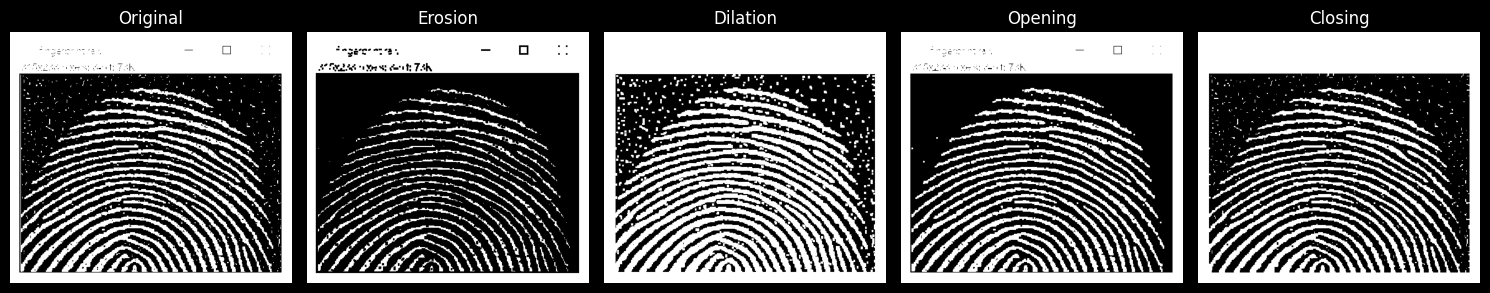

In [12]:
images = [img, eroded, dilated, opened, closed]
titles = ["Original", "Erosion", "Dilation", "Opening", "Closing"]

plt.figure(figsize=(15, 3))
for i in range(len(images)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=1)
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 15. A second example with gaps and holes

This example shows more clearly when opening and closing are useful.


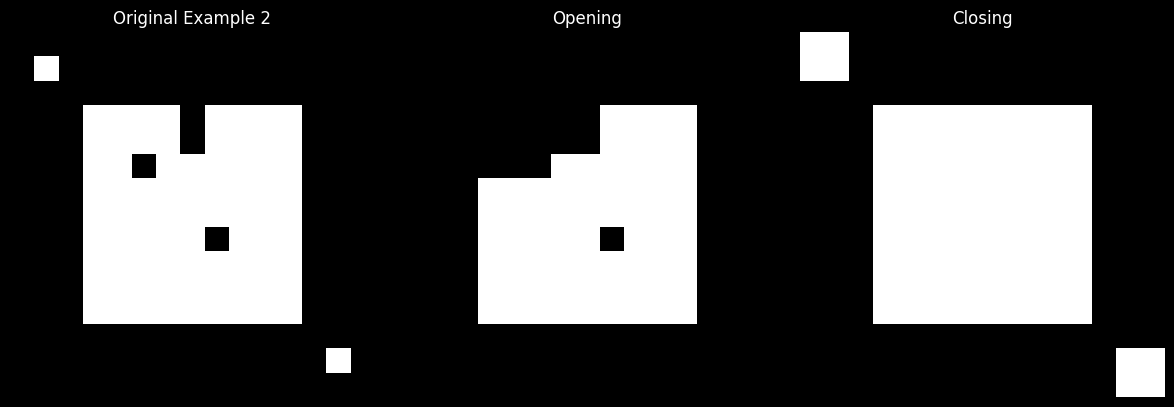

In [16]:
img = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week11/finger.png", cv2.IMREAD_GRAYSCALE)

img2 = np.zeros((15, 15), dtype=np.uint8)

# Large rectangle
img2[3:12, 3:12] = 1

# Add small holes
img2[5, 5] = 0
img2[8, 8] = 0

# Add a gap in the boundary
img2[3:5, 7] = 0

# Add noise
img2[1, 1] = 1
img2[13, 13] = 1


opened2 = cv2.morphologyEx(img2, cv2.MORPH_OPEN, kernel)
closed2 = cv2.morphologyEx(img2, cv2.MORPH_CLOSE, kernel)


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img2, cmap='gray', vmin=0, vmax=1)
plt.title("Original Example 2")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(opened2, cmap='gray', vmin=0, vmax=1)
plt.title("Opening")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(closed2, cmap='gray', vmin=0, vmax=1)
plt.title("Closing")
plt.axis("off")

plt.tight_layout()
plt.show()

## 16. Interpretation summary

### Erosion
Best for:
- removing small foreground noise
- shrinking objects
- separating touching objects

### Dilation
Best for:
- growing objects
- connecting nearby components
- filling very small gaps

### Opening
Best for:
- removing small bright noise
- preserving the general shape of larger objects

### Closing
Best for:
- filling small dark holes
- connecting small breaks inside objects


## 17. Student Tasks

### Task 1
Create a binary image of size **20 × 20** that contains:
- one square
- one circle-like object
- at least two isolated noise pixels

Then display the image.

### Task 2
Use a **3 × 3** kernel and apply:
- erosion
- dilation
- opening
- closing

Display all outputs.

### Task 3
Change the kernel to **5 × 5** and compare the results with the **3 × 3** kernel.

Write 3–4 sentences about:
- which operation changed the object the most
- which operation removed noise best
- which operation filled holes best

### Task 4
Create a binary image with two nearby objects separated by a one-pixel gap.
Apply dilation and explain whether the objects become connected.

### Task 5
Create an object with a small hole inside it.
Apply closing and explain the result.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

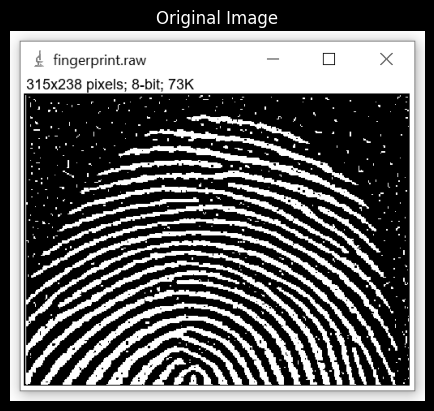

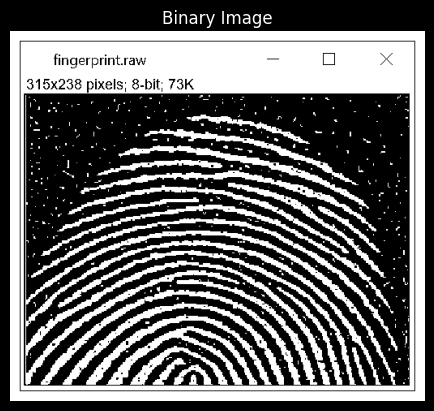

In [40]:

img = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week11/finger.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# Convert to binary
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')
plt.show()

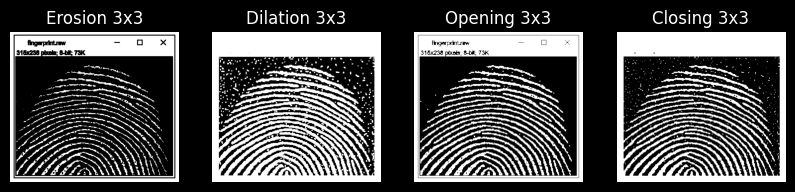

In [41]:
kernel3 = np.ones((3,3), np.uint8)

erosion3 = cv2.erode(binary, kernel3)
dilation3 = cv2.dilate(binary, kernel3)
opening3 = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel3)
closing3 = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel3)

titles = ["Erosion 3x3", "Dilation 3x3", "Opening 3x3", "Closing 3x3"]
imgs = [erosion3, dilation3, opening3, closing3]

plt.figure(figsize=(10,3))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(imgs[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

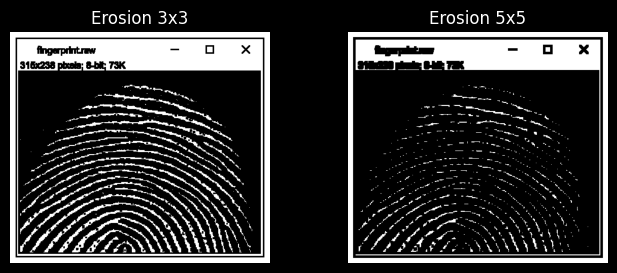

In [42]:
kernel5 = np.ones((5,5), np.uint8)

erosion5 = cv2.erode(binary, kernel5)
dilation5 = cv2.dilate(binary, kernel5)
opening5 = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel5)
closing5 = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel5)

plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.imshow(erosion3, cmap='gray')
plt.title("Erosion 3x3")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(erosion5, cmap='gray')
plt.title("Erosion 5x5")
plt.axis('off')

plt.show()

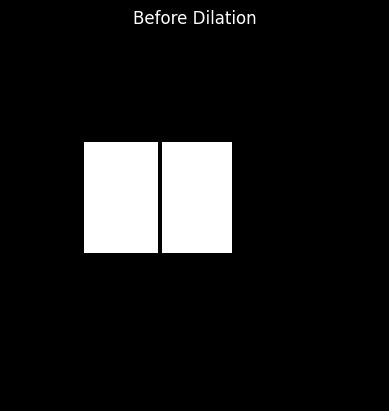

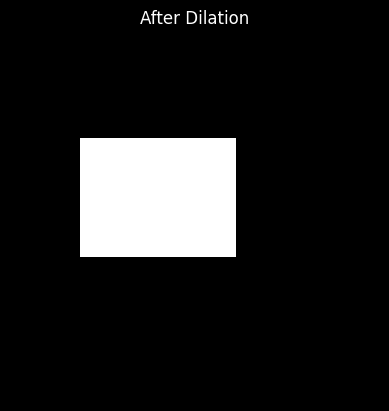

In [43]:
img2 = np.zeros((100, 100), dtype=np.uint8)

img2[30:60, 20:40] = 255
img2[30:60, 41:60] = 255   # 1-pixel gap

plt.imshow(img2, cmap='gray')
plt.title("Before Dilation")
plt.axis('off')
plt.show()

dilated = cv2.dilate(img2, kernel3)

plt.imshow(dilated, cmap='gray')
plt.title("After Dilation")
plt.axis('off')
plt.show()

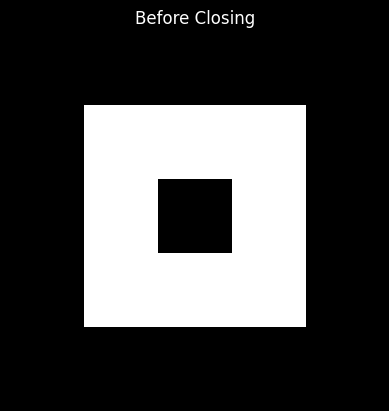

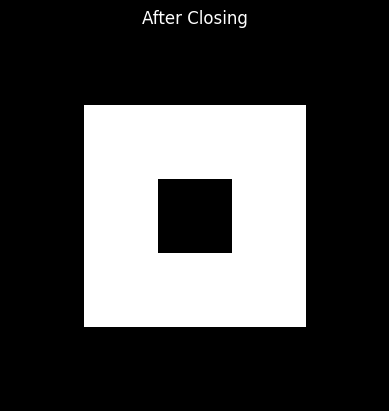

In [44]:
img3 = np.zeros((100, 100), dtype=np.uint8)

img3[20:80, 20:80] = 255   # big square
img3[40:60, 40:60] = 0     # hole

plt.imshow(img3, cmap='gray')
plt.title("Before Closing")
plt.axis('off')
plt.show()

closed = cv2.morphologyEx(img3, cv2.MORPH_CLOSE, kernel3)

plt.imshow(closed, cmap='gray')
plt.title("After Closing")
plt.axis('off')
plt.show()

## 18. Challenge Exercises

### Challenge 1
Without using `cv2.morphologyEx`, implement **opening** manually by combining:
1. erosion
2. dilation

### Challenge 2
Without using `cv2.morphologyEx`, implement **closing** manually by combining:
1. dilation
2. erosion

### Challenge 3
Test three different structuring elements:
- 3 × 3 square
- 5 × 5 square
- cross-shaped kernel

Then compare how they affect the same binary image.

### Challenge 4
Generate a binary image with multiple noisy objects and try to:
- remove isolated foreground pixels with opening
- fill small holes with closing

Explain why the order of operations matters.

### Challenge 5
Write a function:

```python
def show_morphology_results(binary_image, kernel):
    ...
```

The function should display:
- original
- eroded
- dilated
- opened
- closed


In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [46]:
def manual_opening(binary, kernel):
    eroded = cv2.erode(binary, kernel)
    opened = cv2.dilate(eroded, kernel)
    return opened

In [47]:
def manual_closing(binary, kernel):
    dilated = cv2.dilate(binary, kernel)
    closed = cv2.erode(dilated, kernel)
    return closed

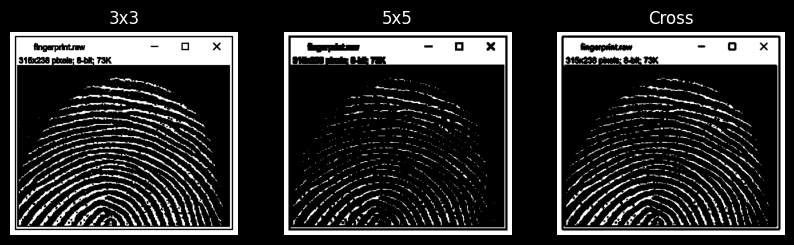

In [48]:
# Load image (CHANGE PATH)
img = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week11/finger.png", cv2.IMREAD_GRAYSCALE)

_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Kernels
kernel_3 = np.ones((3,3), np.uint8)
kernel_5 = np.ones((5,5), np.uint8)
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5))

# Apply erosion
e3 = cv2.erode(binary, kernel_3)
e5 = cv2.erode(binary, kernel_5)
ec = cv2.erode(binary, kernel_cross)

# Show comparison
titles = ["3x3", "5x5", "Cross"]
imgs = [e3, e5, ec]

plt.figure(figsize=(10,3))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(imgs[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

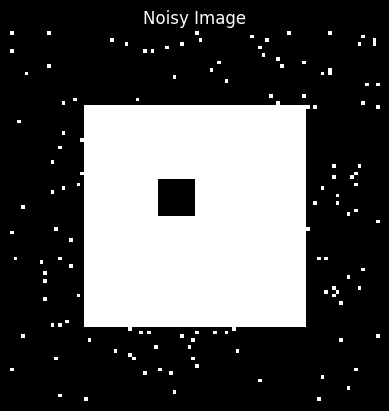

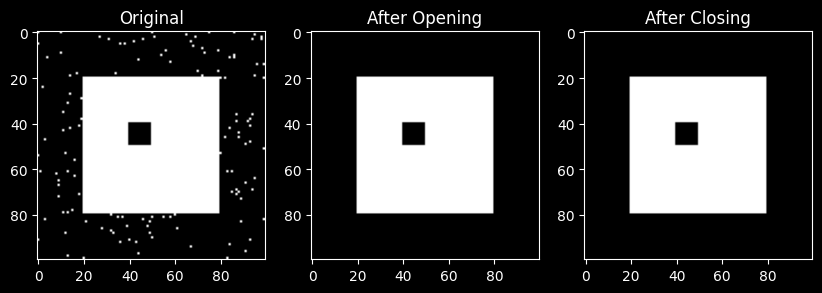

In [50]:
# Create noisy binary image
noisy = np.zeros((100,100), dtype=np.uint8)

# Main object
noisy[20:80, 20:80] = 255

# Add noise pixels
np.random.seed(0)
for _ in range(200):
    x = np.random.randint(0,100)
    y = np.random.randint(0,100)
    noisy[x,y] = 255

# Add small hole
noisy[40:50, 40:50] = 0

plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.axis('off')
plt.show()

# Opening removes noise
clean = manual_opening(noisy, kernel_3)

# Closing fills holes
filled = manual_closing(clean, kernel_3)

plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(noisy, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(clean, cmap='gray')
plt.title("After Opening")

plt.subplot(1,3,3)
plt.imshow(filled, cmap='gray')
plt.title("After Closing")

plt.show()

In [51]:
def show_morphology_results(binary_image, kernel):
    eroded = cv2.erode(binary_image, kernel)
    dilated = cv2.dilate(binary_image, kernel)
    opened = cv2.dilate(eroded, kernel)
    closed = cv2.erode(dilated, kernel)

    titles = ["Original", "Erosion", "Dilation", "Opening", "Closing"]
    images = [binary_image, eroded, dilated, opened, closed]

    plt.figure(figsize=(10,3))
    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.show()

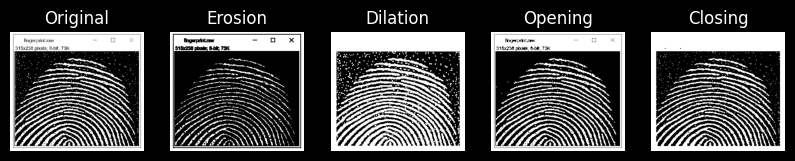

In [52]:
kernel = np.ones((3,3), np.uint8)
show_morphology_results(binary, kernel)

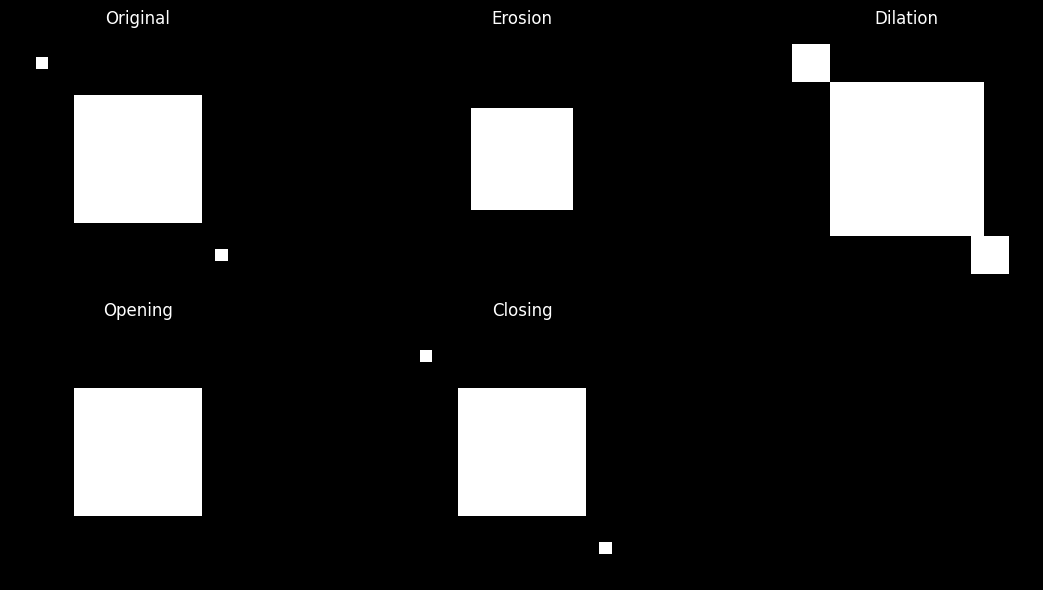

In [53]:
# Starter template

student_img = np.zeros((20, 20), dtype=np.uint8)

# Example object
student_img[5:15, 5:15] = 1

# Add noise
student_img[2, 2] = 1
student_img[17, 16] = 1

student_kernel = np.ones((3, 3), dtype=np.uint8)

student_eroded = cv2.erode(student_img, student_kernel, iterations=1)
student_dilated = cv2.dilate(student_img, student_kernel, iterations=1)
student_opened = cv2.morphologyEx(student_img, cv2.MORPH_OPEN, student_kernel)
student_closed = cv2.morphologyEx(student_img, cv2.MORPH_CLOSE, student_kernel)

plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(student_img, cmap='gray', vmin=0, vmax=1)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(student_eroded, cmap='gray', vmin=0, vmax=1)
plt.title("Erosion")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(student_dilated, cmap='gray', vmin=0, vmax=1)
plt.title("Dilation")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(student_opened, cmap='gray', vmin=0, vmax=1)
plt.title("Opening")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(student_closed, cmap='gray', vmin=0, vmax=1)
plt.title("Closing")
plt.axis("off")

plt.tight_layout()
plt.show()

## 20. Reflection Questions

1. Why does erosion remove small objects?
2. Why is opening better than erosion alone for noise removal?
3. Why does closing help with holes inside foreground objects?
4. How does kernel size affect the final result?
5. When would you choose opening before closing, and when would you choose closing before opening?


## 21. Extra

Use a real black-and-white image or generate your own synthetic binary image.  
Then:

- apply all four operations
- test at least two different kernels
- write a short comparison report with figures

Recommended report sections:
1. image description
2. kernel used
3. results of each morphology operation
4. conclusion


## 22. Conclusion

Morphological operations are fundamental tools for binary image analysis.

- **Erosion** shrinks foreground objects.
- **Dilation** expands foreground objects.
- **Opening** removes small foreground noise.
- **Closing** fills small holes and gaps.

These operations are widely used in preprocessing, segmentation, object cleanup, and shape analysis.
